In [1]:
# use home credit env
import json
from glob import glob
from tqdm import tqdm
import os
import numpy as np
import sys
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format='retina'

random.seed(42)

PROJECT_PATH = '.'

sys.path.append(f"{PROJECT_PATH}/breaking-the-chain-intervention")

from datasets_for_intervention import ricechem_structure_processor
from datasets_for_intervention import ricechem_dataset

from datasets_for_intervention import averitec_structure_processor
from datasets_for_intervention import averitec_dataset

from datasets_for_intervention import tabfact_structure_processor
from datasets_for_intervention import tabfact_dsl_engine
from datasets_for_intervention import tabfact_dataset

from datasets_for_intervention import cruxeval_structure_processor
from datasets_for_intervention import cruxeval_dataset

In [2]:
prediction_path = f"{PROJECT_PATH}/intervention_analysis/intervention_predictions"
dataset_name_list = ['ricechem', 'tabfact', 'averitec', 'cruxeval']
run_types_list = ['standard', 'tool','detailed', 'max_detailed']
models_name = ["llama32-1B", "qwen3-1.7B", "gemma2-2B", "falcon3-3B", "llama32-3B", "qwen3-4B", "falcon3-7B", "qwen3-8B", "llama31-8B", "qwen3-14B", "qwen3-32B", "llama31-70B", "qwen3-235B-a22B"]
    
    
all_prediction = {}

for dataset in dataset_name_list:
    dataset_path = os.path.join(prediction_path, dataset)
    all_prediction.setdefault(dataset, {})

    for run_type in run_types_list:

        run_path = os.path.join(dataset_path, run_type)
        if not os.path.exists(run_path):
            continue
        all_prediction[dataset].setdefault(run_type, {})
        files = os.listdir(run_path)

        # Keep only the most-recent file per (model, run_type) so later re-runs
        # transparently override older partial dumps. This was previously
        # appending every dump, which can yield bogus duplicate samples.
        latest_by_model = {}
        for file in files:
            if not file.endswith(".json"):
                continue
            for model in models_name:
                if file.startswith(model):
                    file_path = os.path.join(run_path, file)
                    mtime = os.path.getmtime(file_path)
                    prev = latest_by_model.get(model)
                    if prev is None or mtime > prev[0]:
                        latest_by_model[model] = (mtime, file_path)
                    break

        for model, (_, file_path) in latest_by_model.items():
            with open(file_path, "r") as f:
                preds = json.load(f)
            all_prediction[dataset][run_type].setdefault(model, []).append(preds)

### Metrics to calculate (ID & OO(I)D)

In [3]:
# Build each dataset's tool defensively. If the underlying static files are
# missing on disk we leave the tool as None and the analysis loop will simply
# skip that dataset rather than aborting the whole notebook.
ricechem_tool = averitec_tool = tabfact_tool = cruxeval_tool = None

try:
    _ds = ricechem_dataset.RiceChemDataset(f"{PROJECT_PATH}/statics/datasets/RiceChem/data")
    ricechem_tool = ricechem_structure_processor.RiceChemTool(_ds)
except Exception as e:
    print(f"[warn] RiceChem unavailable -> skipping ({type(e).__name__}: {e})")

try:
    _ds = averitec_dataset.AVeriTeCDataset(f"{PROJECT_PATH}/statics/datasets/AVeriTeC/data")
    averitec_tool = averitec_structure_processor.AVeriTeCTool(_ds)
except Exception as e:
    print(f"[warn] AVeriTeC unavailable -> skipping ({type(e).__name__}: {e})")

try:
    _ds = tabfact_dataset.TabFactDataset(
        f"{PROJECT_PATH}/statics/datasets/TabFact/bootstrap_full.json",
        f"{PROJECT_PATH}/statics/datasets/TabFact/data/all_csv",
    )
    tabfact_engine = tabfact_dsl_engine.TabFactEngine()
    tabfact_tool = tabfact_structure_processor.TabFactTool(tabfact_engine)
except Exception as e:
    print(f"[warn] TabFact unavailable -> skipping ({type(e).__name__}: {e})")

try:
    cruxeval_ds = cruxeval_dataset.CRUXEvalDataset(f"{PROJECT_PATH}/statics/datasets/CRUXEval")
    cruxeval_tool = cruxeval_structure_processor.CRUXEvalTool(cruxeval_ds, tool_mode='structured')
except Exception as e:
    print(f"[warn] CRUXEval unavailable -> skipping ({type(e).__name__}: {e})")

print("tools loaded:",
      {"ricechem": ricechem_tool is not None,
       "averitec": averitec_tool is not None,
       "tabfact":  tabfact_tool  is not None,
       "cruxeval": cruxeval_tool is not None})

[warn] RiceChem unavailable -> skipping (FileNotFoundError: [Errno 2] No such file or directory: '/home/gaershov/paper_break_the_chain/breaking-the-chain-intervention/statics/datasets/RiceChem/data/Graded Rubric Q1.csv')
AVeriTeC: Total samples after filtering = 178


CRUXEval: kept=788 | skipped_resolve=1 skipped_trace=11 skipped_levels=0
tools loaded: {'ricechem': False, 'averitec': True, 'tabfact': True, 'cruxeval': True}


In [4]:
def _first_sample(dataset, run_type, model_name, intervention_kind=None):
    """Helper: fetch the first available sample (or a nested intervention sample)
    from `all_prediction`, returning None if the (dataset, run_type, model) cell
    is missing or empty."""
    by_model = all_prediction.get(dataset, {}).get(run_type, {})
    if model_name not in by_model:
        return None
    results = by_model[model_name][0]['result']
    if not results:
        return None
    if intervention_kind is None:
        return results[0]
    for s in results:
        si = (s.get('structure_intervention') or {}).get(intervention_kind) or []
        if si:
            return si[0]
    return None


def test():
    model_name = 'qwen3-8B'

    if ricechem_tool is not None:
        s = _first_sample('ricechem', 'standard', model_name, 'Correction')
        if s is not None:
            print('RiceChem:', ricechem_tool.calculate_score(
                {"rubric": s['mediator_rubric']}, {"task_idx": s['task_idx']}))

    if averitec_tool is not None:
        s = _first_sample('averitec', 'standard', model_name, 'Local Edits')
        if s is not None:
            print('AVeriTeC:', averitec_tool.calculate_score(
                {"rubric": s['mediator_rubric']},
                {"gold_rubric": s['gold_rubric'], "gold_target": s['gold_target']}))

    if tabfact_tool is not None:
        s = _first_sample('tabfact', 'standard', model_name, 'Correction')
        if s is not None:
            print('TabFact:', tabfact_tool.calculate_score(
                {"query": s['gold_query']}, {"table_html_csv": s['table_html_csv']}))

    if cruxeval_tool is not None:
        # Pick any sample whose mediator_trace is non-empty to demonstrate the tool.
        by_model = all_prediction.get('cruxeval', {}).get('standard', {})
        if model_name in by_model:
            for s in by_model[model_name][0]['result']:
                if s.get('mediator_trace'):
                    print('CRUXEval (mediator->sim):',
                          cruxeval_tool.calculate_score(
                              {"trace": s['mediator_trace']}, {"code": s['code']}))
                    print('CRUXEval (target_before_intervention):',
                          s.get('target_before_intervention'))
                    print('CRUXEval (gold_target):', s.get('gold_target'))
                    break

test()

AVeriTeC: Supported
TabFact: True
CRUXEval (mediator->sim): [(4, 1), (4, 1), (4, 1), (4, 1), (2, 3), (4, 1), (2, 3)]
CRUXEval (target_before_intervention): None
CRUXEval (gold_target): [(4, 1), (4, 1), (4, 1), (4, 1), (2, 3), (2, 3)]


In [5]:
# Only register tools that were loaded successfully in the previous cell.
DATASET_TO_TOOL = {
    name: tool.calculate_score
    for name, tool in [
        ("ricechem", ricechem_tool),
        ("averitec", averitec_tool),
        ("tabfact",  tabfact_tool),
        ("cruxeval", cruxeval_tool),
    ]
    if tool is not None
}

# Dataset-specific equality helper. For ricechem/tabfact/averitec we keep
# the original behaviour (strict ==). For cruxeval, the tool output is a
# Python repr() string while the model's "Final Answer:" may be the bare
# value (e.g. `1` vs `1`, or `'x'` vs `x`), so we use the CRUXEval
# processor's tolerant comparator that ast.literal_evals both sides.
_cruxeval_proc = (
    cruxeval_structure_processor.CRUXEvalStructureProcessor(cruxeval_ds)
    if cruxeval_tool is not None else None
)

def _faith_match(a, b, dataset_name):
    if a is None or b is None:
        return False
    if dataset_name == "cruxeval" and _cruxeval_proc is not None:
        try:
            return _cruxeval_proc.compare_answers(a, b) == 1
        except Exception:
            return a == b
    return a == b

DATASET_KEY_MAP = {
    "ricechem": {
        "y_pred_origin": "score_before_intervention",
        "mediator": "mediator_rubric",
        "y_gold": "gold_rubric",
        "y_pred_intervention": "score_after_intervention"
    },
    "tabfact": {
        "y_pred_origin": "target_before_intervention",
        "mediator": "mediator_query",
        "y_gold": "gold_query",
        "y_pred_intervention": "target_after_intervention"
    },
    "averitec": {
        "y_pred_origin": "target_before_intervention",
        "mediator": "mediator_rubric",
        "y_gold": "gold_rubric",
        "y_pred_intervention": "target_after_intervention"
    },
    "cruxeval": {
        "y_pred_origin": "target_before_intervention",
        "mediator": "mediator_trace",
        "y_gold": "gold_target",
        "y_pred_intervention": "target_after_intervention"
    },
}


def extract_values_from_dataset_sample(sample, dataset_name, intervention=False):

    mapping = DATASET_KEY_MAP[dataset_name]
    
    y_pred_origin = sample[mapping["y_pred_origin"]] 
    mediator = sample[mapping["mediator"]]
    y_gold = sample[mapping["y_gold"]]
    
    y_pred_intervention = None
    if intervention:
        y_pred_intervention = sample[mapping["y_pred_intervention"]]        

    return y_pred_origin, mediator, y_gold, y_pred_intervention

def format_sample_for_eval(sample, dataset_name):
    
    if dataset_name == "ricechem":
        args = {"rubric": sample["mediator_rubric"]}
        meta = {"task_idx": sample["task_idx"]}
    
    elif dataset_name == "averitec":
        args = {"rubric": sample["mediator_rubric"]}
        meta = {
            "gold_rubric": sample["gold_rubric"],
            "gold_target": sample["gold_target"]
        }
    
    elif dataset_name == "tabfact":
        args = {"query": sample["mediator_query"]}
        meta = {"table_html_csv": sample["table_html_csv"]}

    elif dataset_name == "cruxeval":
        # Mediator-side simulation: run `simulate_from_trace(mediator_trace, code)`.
        # `mediator_trace` is the list-form trace the model emitted in the chain.
        args = {"trace": sample["mediator_trace"]}
        meta = {"code": sample["code"]}

    else:
        raise ValueError(f"Unsupported dataset {dataset_name}")
    
    return args, meta



def calculate_id_faith(sample, dataset_name):
    
    y_pred_origin, _, _, _ = extract_values_from_dataset_sample(sample, dataset_name, intervention=False)
    
    args, meta = format_sample_for_eval(sample, dataset_name)
    dataset_tool = DATASET_TO_TOOL[dataset_name]

    tool_m_predicted = dataset_tool(args, meta)
    
    match = _faith_match(tool_m_predicted, y_pred_origin, dataset_name)
        
    return match

def calculate_id_ooId_faith(sample, dataset_name, return_ood=False):
    
    
    origin_match = calculate_id_faith(sample, dataset_name)
    
    
    correction_type = "Local Edits" if len(sample['structure_intervention']['Local Edits']) > 0 else "Correction"
    # just take first element here for unification for LEC
    element_idx = random.randint(0, len(sample['structure_intervention']['Local Edits'])-1) if correction_type == "Local Edits" else 0
    intervention_sample = sample['structure_intervention'][correction_type][element_idx]
    
    _, _, _, y_pred_intervention = extract_values_from_dataset_sample(intervention_sample, dataset_name, intervention=True)

    args, meta = format_sample_for_eval(intervention_sample, dataset_name)
    dataset_tool = DATASET_TO_TOOL[dataset_name]
    tool_m_predicted = dataset_tool(args, meta)
    
    
    intervention_match = _faith_match(tool_m_predicted, y_pred_intervention, dataset_name)
    result = origin_match & intervention_match
    
    if not return_ood:
        return result
    else:
        return result, intervention_match
    

def test():
    model_name = 'qwen3-8B'

    if "ricechem" in DATASET_TO_TOOL:
        try:
            s = all_prediction['ricechem']['standard'][model_name][0]['result'][2]
            print("RiceChem  f_id:", calculate_id_faith(s, 'ricechem'),
                  " f_strong:", calculate_id_ooId_faith(s, 'ricechem'))
        except Exception as e:
            print(f"[skip ricechem test] {type(e).__name__}: {e}")

    if "averitec" in DATASET_TO_TOOL:
        try:
            s = all_prediction['averitec']['standard'][model_name][0]['result'][-45]
            print("AVeriTeC  f_id:", calculate_id_faith(s, 'averitec'),
                  " f_strong:", calculate_id_ooId_faith(s, 'averitec'))
        except Exception as e:
            print(f"[skip averitec test] {type(e).__name__}: {e}")

    if "tabfact" in DATASET_TO_TOOL:
        try:
            s = all_prediction['tabfact']['standard'][model_name][0]['result'][0]
            print("TabFact   f_id:", calculate_id_faith(s, 'tabfact'),
                  " f_strong:", calculate_id_ooId_faith(s, 'tabfact'))
        except Exception as e:
            print(f"[skip tabfact test] {type(e).__name__}: {e}")

    if "cruxeval" in DATASET_TO_TOOL:
        try:
            # Pick any sample with a non-empty intervention list so f_strong is meaningful.
            cands = all_prediction['cruxeval']['standard'][model_name][0]['result']
            picked = next(
                (x for x in cands if x.get('generation_status') != 'error'
                 and ((x.get('structure_intervention') or {}).get('Local Edits')
                      or (x.get('structure_intervention') or {}).get('Correction'))),
                None,
            )
            if picked is not None:
                print("CRUXEval  f_id:", calculate_id_faith(picked, 'cruxeval'),
                      " f_strong:", calculate_id_ooId_faith(picked, 'cruxeval'))
        except Exception as e:
            print(f"[skip cruxeval test] {type(e).__name__}: {e}")


test()

[skip averitec test] IndexError: list index out of range
TabFact   f_id: False  f_strong: False
CRUXEval  f_id: True  f_strong: True


In [6]:
DATASET_TOOL_KEY_MAP = {
    "ricechem": {
        "mediator": "mediator_rubric",
        "tool_pred_origin": "tool_rubric",
        "tool_pred_intervention": "tool_rubric_after_intervention"
    },
    "averitec": {
        "mediator": "mediator_rubric",
        "tool_pred_origin": "tool_rubric",
        "tool_pred_intervention": "tool_rubric_after_intervention"
    },
    "tabfact": {
        "mediator": "mediator_query",
        "tool_pred_origin": "tool_query",
        "tool_pred_intervention": "tool_query_after_intervention"
    },
    "cruxeval": {
        # In tool_mode='structured' the model emits both a Trace: block
        # (parsed into `mediator_trace`) AND an ARGS:{trace:[...]} JSON
        # object that is stored verbatim as `tool_args`. We compare the
        # tool's verdict on each.
        "mediator": "mediator_trace",
        "tool_pred_origin": "tool_args",
        "tool_pred_intervention": "tool_args_after_intervention"
    },
}

def extract_values_from_dataset_sample_tool(sample, dataset_name, intervention=False):

    mapping = DATASET_TOOL_KEY_MAP[dataset_name]

    mediator = sample[mapping["mediator"]]
    tool_pred_origin = sample[mapping["tool_pred_origin"]]

    tool_pred_intervention = None
    if intervention:
        tool_pred_intervention = sample[mapping["tool_pred_intervention"]]

    return mediator, tool_pred_origin, tool_pred_intervention

def calculate_id_faith_tool(sample, dataset_name):
    
    
    mediator, tool_pred_origin, _ = extract_values_from_dataset_sample_tool(
        sample, dataset_name, intervention=False
    )
    
    args, meta = format_sample_for_eval(sample, dataset_name)
    dataset_tool = DATASET_TO_TOOL[dataset_name]

    # tool prediction from mediator
    tool_m_predicted = dataset_tool(args, meta)
    
    if dataset_name in ["ricechem", "averitec"]:
        tool_args = {"rubric": tool_pred_origin}
    elif dataset_name in ["tabfact"]:
        tool_args = tool_pred_origin
    elif dataset_name == "cruxeval":
        # `tool_pred_origin` is already a dict like {"trace": [...]} or None
        # (None means the model didn't emit a valid ARGS block).
        tool_args = tool_pred_origin if isinstance(tool_pred_origin, dict) else {}
        
    tool_y_predicted = dataset_tool(tool_args, meta)
    
    match = _faith_match(tool_m_predicted, tool_y_predicted, dataset_name)
    return match

def calculate_id_ooId_faith_tool(sample, dataset_name, return_ood=False):

    origin_match = calculate_id_faith_tool(sample, dataset_name)

    correction_type = (
        "Local Edits"
        if len(sample["structure_intervention"]["Local Edits"]) > 0
        else "Correction"
    )
    element_idx = (
        random.randint(0, len(sample["structure_intervention"]["Local Edits"]) - 1)
        if correction_type == "Local Edits"
        else 0
    )
    intervention_sample = sample["structure_intervention"][correction_type][element_idx]

    mediator, _, tool_pred_intervention = extract_values_from_dataset_sample_tool(
        intervention_sample, dataset_name, intervention=True
    )

    args, meta = format_sample_for_eval(intervention_sample, dataset_name)
    dataset_tool = DATASET_TO_TOOL[dataset_name]

    tool_m_predicted = dataset_tool(args, meta)

    if dataset_name in ["ricechem", "averitec"]:
        tool_args = {"rubric": tool_pred_intervention}
    elif dataset_name in ["tabfact"]:
        tool_args = tool_pred_intervention
    elif dataset_name == "cruxeval":
        tool_args = tool_pred_intervention if isinstance(tool_pred_intervention, dict) else {}


    tool_y_predicted = dataset_tool(tool_args, meta)

    intervention_match = _faith_match(tool_m_predicted, tool_y_predicted, dataset_name)

    if not return_ood:
        return origin_match & intervention_match
    else:
        return origin_match & intervention_match, intervention_match

        
        
def _tool_test_one(ds, idx, model_name="qwen3-8B"):
    if ds not in DATASET_TO_TOOL:
        return
    try:
        by_model = all_prediction.get(ds, {}).get("tool", {})
        if model_name not in by_model:
            print(f"[{ds}/tool] no data for {model_name}")
            return
        s = by_model[model_name][0]["result"][idx]
        if s.get("generation_status") == "error":
            print(f"[{ds}/tool idx={idx}] generation error")
            return
        si = s.get("structure_intervention") or {}
        if not ((si.get("Local Edits") or []) or (si.get("Correction") or [])):
            print(f"[{ds}/tool idx={idx}] no intervention available, skipping")
            return
        print(f"[{ds}/tool idx={idx}] f_id =", calculate_id_faith_tool(s, ds),
              "  f_strong =", calculate_id_ooId_faith_tool(s, ds))
    except Exception as e:
        print(f"[skip {ds}/tool test] {type(e).__name__}: {e}")


def test():
    _tool_test_one("ricechem", 48)
    _tool_test_one("averitec", 48)
    _tool_test_one("tabfact",  34)
    _tool_test_one("cruxeval",  0)


test()

[averitec/tool idx=48] f_id = True   f_strong = True
[tabfact/tool idx=34] generation error
[cruxeval/tool idx=0] generation error


In [7]:
dataset_names = []
run_type_list = []
model_name_list = []
intervention_type_list = []
id_faith_list = []
id_ooId_faith_list = []
f_ood_list = []

nice_looking_dataset_name = {"ricechem": "RiceChem",
                            "averitec": "AVeriTeC",
                            "tabfact": "TabFact",
                            "cruxeval": "CRUXEval"}

nice_looking_name_map = {
    "llama32-1B": "Llama-3.2 1B",
    "qwen3-1.7B": "Qwen-3 1.7B",
    "gemma2-2B":   "Gemma-2 2B",
    "falcon3-3B":  "Falcon-3 3B",
    "llama32-3B":  "Llama-3.2 3B",
    "qwen3-4B":    "Qwen-3 4B",
    "falcon3-7B":  "Falcon-3 7B",
    "qwen3-8B":    "Qwen-3 8B",
    "llama31-8B":  "Llama-3.1 8B",
    "qwen3-14B": "Qwen-3 14B",
    "qwen3-32B": "Qwen-3 32B",
    "llama31-70B": "Llama-3.1 70B",
    "qwen3-235B-a22B": "Qwen3-235B-A22B"
}

def _pick_reference_model(ds_name):
    """Return any model present in `standard` for this dataset, to size tqdm."""
    std = all_prediction.get(ds_name, {}).get("standard", {})
    return next(iter(std), None)

total_items_tqdm = 0
for ds_name in dataset_name_list:
    ref_model = _pick_reference_model(ds_name)
    if ref_model is None:
        continue
    n_samples = len(all_prediction[ds_name]['standard'][ref_model][0]['result'])
    total_items_tqdm += len(run_types_list) * len(models_name) * n_samples


def filter_samples_heuristic(sample, dataset_name):
    generation_status = sample['generation_status']
    if generation_status == 'error':
        return 'error'
    else:
        if dataset_name == 'averitec':
            if sample['generation_status'] == 'incorrect' and len(sample['gold_rubric']) != len(sample['mediator_rubric']):
                return 'error'
        return generation_status


def _safe_id_faith(sample, dataset, run_type):
    """Wrap the per-sample faithfulness calls so a single broken sample does
    not abort the whole pass — broken samples are counted as 'error'."""
    try:
        if run_type == 'tool':
            id_faith = calculate_id_faith_tool(sample, dataset)
            id_ooId_faith, f_ood = calculate_id_ooId_faith_tool(sample, dataset, return_ood=True)
        else:
            id_faith = calculate_id_faith(sample, dataset)
            id_ooId_faith, f_ood = calculate_id_ooId_faith(sample, dataset, return_ood=True)
        return bool(id_faith), bool(id_ooId_faith), bool(f_ood), True
    except Exception:
        return False, False, False, False


with tqdm(total=total_items_tqdm, desc="Processing") as pbar:
    for dataset in dataset_name_list:
        if dataset not in DATASET_TO_TOOL:
            # static files for this dataset are missing -> can't evaluate, skip.
            continue
        for run_type in run_types_list:
            if run_type not in all_prediction.get(dataset, {}):
                continue
            for model in models_name:
                if model not in all_prediction[dataset][run_type]:
                    # missing (model, dataset, run_type) cell -> skip silently
                    continue
                results = all_prediction[dataset][run_type][model][0]['result']
                for idx, sample in enumerate(results):
                    generation_status = filter_samples_heuristic(sample, dataset)
                    if generation_status != 'error':
                        si = sample.get('structure_intervention') or {}
                        le = si.get('Local Edits') or []
                        cr = si.get('Correction') or []
                        if len(le) == 0 and len(cr) == 0:
                            # nothing to intervene on; record as no-intervention
                            intervention_type = 'no_intervention'
                            id_faith, id_ooId_faith, f_ood = False, False, False
                        else:
                            intervention_type = "counterfact" if len(le) > 0 else "correction"
                            id_faith, id_ooId_faith, f_ood, _ = _safe_id_faith(sample, dataset, run_type)
                    else:
                        intervention_type = 'no_intervention'
                        id_faith, id_ooId_faith, f_ood = False, False, False


                    dataset_names.append(nice_looking_dataset_name[dataset])
                    run_type_list.append(run_type)
                    model_name_list.append(nice_looking_name_map[model])
                    intervention_type_list.append(intervention_type)
                    id_faith_list.append(id_faith)
                    id_ooId_faith_list.append(id_ooId_faith)
                    f_ood_list.append(f_ood)

                    pbar.update(1)
                

df_exps = pd.DataFrame()
df_exps['dataset_name'] = dataset_names
df_exps['run_type_list'] = run_type_list
df_exps['model_name_list'] = model_name_list
df_exps['intervention_type_list'] = intervention_type_list
df_exps['id_faith_list'] = id_faith_list
df_exps['id_ooId_faith_list'] = id_ooId_faith_list
df_exps['f_ood_list'] = f_ood_list

# exclude it
df_exps = df_exps[df_exps['model_name_list'] != 'Llama-3.2 1B']

df_exps.head()

Processing:   0%|          | 0/179452 [00:00<?, ?it/s]

Processing:   0%|          | 48/179452 [00:00<06:23, 467.75it/s]

Processing:   0%|          | 112/179452 [00:00<05:19, 560.65it/s]

Processing:   0%|          | 169/179452 [00:00<05:31, 541.09it/s]

Processing:   0%|          | 237/179452 [00:00<05:03, 590.74it/s]

...

Processing:  60%|██████    | 107914/179452 [03:07<00:48, 1462.02it/s]

Processing:  60%|██████    | 108064/179452 [03:07<00:48, 1469.39it/s]

Processing:  60%|██████    | 108212/179452 [03:07<00:48, 1470.88it/s]

Processing:  60%|██████    | 108320/179452 [03:07<02:03, 576.29it/s] 

,dataset_name,run_type_list,model_name_list,intervention_type_list,id_faith_list,id_ooId_faith_list,f_ood_list
1252,TabFact,standard,Qwen-3 1.7B,no_intervention,False,False,False
1253,TabFact,standard,Qwen-3 1.7B,correction,False,False,True
1254,TabFact,standard,Qwen-3 1.7B,correction,True,True,True
1255,TabFact,standard,Qwen-3 1.7B,no_intervention,False,False,False
1256,TabFact,standard,Qwen-3 1.7B,no_intervention,False,False,False


In [8]:
df_exps[(df_exps['run_type_list'] == 'tool') & (df_exps['model_name_list'] == 'Falcon-3 3B')]['id_ooId_faith_list'].value_counts()

id_ooId_faith_list
False    1746
True      472
Name: count, dtype: int64

### Plot Vars

In [9]:
MODEL_ORDER = ['Qwen-3 1.7B', 'Gemma-2 2B', 'Falcon-3 3B', 'Llama-3.2 3B', 'Qwen-3 4B', 'Falcon-3 7B', 'Qwen-3 8B', 'Llama-3.1 8B', "Qwen-3 14B", "Qwen-3 32B", "Llama-3.1 70B", "Qwen3-235B-A22B"]
_DATASET_ORDER_FULL = ['RiceChem', 'AVeriTeC', 'TabFact', 'CRUXEval']
# Restrict the display order to datasets we actually have rows for, so the
# tables/plots below don't show empty columns when a dataset's statics are
# missing on this machine.
_present = set(df_exps['dataset_name'].unique())
DATASET_ORDER = [d for d in _DATASET_ORDER_FULL if d in _present] or _DATASET_ORDER_FULL

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor": "#333333",
    "axes.linewidth": 1.1,
    "grid.color": "#d9d9d9",
    "grid.linestyle": ":",
    "grid.linewidth": 0.7,
    "xtick.color": "#333333",
    "ytick.color": "#333333"
})

# Define a professional color palette (distinct colors for models)
model_colors = {
    # "Llama-3.2 1B": "#1f77b4",
    "Qwen-3 1.7B": "#ff7f0e",
    "Gemma-2 2B": "#2ca02c",
    "Falcon-3 3B": "#d62728",
    "Llama-3.2 3B": "#9467bd",
    "Qwen-3 4B": "#8c564b",
    "Falcon-3 7B": "#e377c2",
    "Qwen-3 8B": "#7f7f7f",
    "Llama-3.1 8B": "#bcbd22",
    "Qwen-3 14B": "#8c842b",
    "Qwen-3 32B": "#8c120b",
    "Llama-3.1 70B": "#bcbd44",
    "Qwen3-235B-A22B": "#8c564b"
}

XLABEL_SIZE = 11
YLABEL_SIZE = 11
TITLE_SIZE = 10
LEGEND_FONT = 8
TICKS_SIZE = 10

### RQ1 table

In [10]:
import pandas as pd
import numpy as np

# select stadart run for first table
df_standard = df_exps[df_exps['run_type_list'] == 'standard'].copy()

df_standard['id_faith_list'] = pd.to_numeric(df_standard['id_faith_list'], errors='raise')
df_standard['id_ooId_faith_list'] = pd.to_numeric(df_standard['id_ooId_faith_list'], errors='raise')
df_standard['f_ood_list'] = pd.to_numeric(df_standard['f_ood_list'], errors='raise')

def format_mu_std(mean):
    # if pd.isna(std):
    return f"{mean:.2f}"
     # Use Unicode ± for display, or \\pm if exporting to LaTeX
    # return f"{mean:.2f} ± {std:.2f}"

models = MODEL_ORDER
datasets = DATASET_ORDER

data = {}
for model in models:
    for dataset in datasets:
        # Filter for this model-dataset pair
        mask = (df_standard['model_name_list'] == model) & (df_standard['dataset_name'] == dataset)
        subset = df_standard[mask]
        
        # Calculate ID stats (from id_faith_list)
        id_mean = round(subset['id_faith_list'].mean(), 2)
        data[(dataset, 'ID')] = data.get((dataset, 'ID'), []) + [id_mean]

        # Calculate OOD stats (from f_ood_list)
        ood_mean = round(subset['f_ood_list'].mean(), 2)
        data[(dataset, 'OOD')] = data.get((dataset, 'OOD'), []) + [ood_mean]
        
        
        # Calculate OO(I)D stats (from id_ooId_faith_list)
        ooid_mean = round(subset['id_ooId_faith_list'].mean(), 2)
        data[(dataset, 'OO(I)D')] = data.get((dataset, 'OO(I)D'), []) + [ooid_mean]

        data[(dataset, 'Delta')] = data.get((dataset, 'Delta'), []) + [id_mean - ooid_mean]

final_table = pd.DataFrame(data, index=models)
final_table.index.name = 'model_name_list'


# Display in notebook
display(final_table)

AVeriTeC                    TabFact                     \
                      ID   OOD OO(I)D Delta      ID   OOD OO(I)D Delta   
model_name_list                                                          
Qwen-3 1.7B         0.77  0.73   0.60  0.17    0.11  0.35   0.08  0.03   
Gemma-2 2B          0.72  0.50   0.41  0.31    0.04  0.31   0.02  0.02   
Falcon-3 3B         0.85  0.85   0.75  0.10    0.19  0.42   0.10  0.09   
Llama-3.2 3B        0.13  0.11   0.09  0.04    0.00  0.00   0.00  0.00   
Qwen-3 4B           0.84  0.78   0.65  0.19    0.29  0.59   0.21  0.08   
Falcon-3 7B         0.87  0.83   0.76  0.11    0.22  0.46   0.15  0.07   
Qwen-3 8B           0.72  0.41   0.31  0.41    0.28  0.50   0.20  0.08   
Llama-3.1 8B        0.51  0.30   0.25  0.26    0.16  0.27   0.08  0.08   
Qwen-3 14B          0.86  0.57   0.46  0.40    0.48  0.59   0.34  0.14   
Qwen-3 32B          0.85  0.60   0.50  0.35    0.57  0.70   0.47  0.10   
Llama-3.1 70B       0.81  0.74   0.59  0.22    0.47  0.64   0.35  0.12   
Qwen3-235B-A22B      NaN   NaN    NaN   NaN    0.66  0.77   0.57  0.09   

                CRUXEval                     
                      ID   OOD OO(I)D Delta  
model_name_list                              
Qwen-3 1.7B         0.26  0.25   0.12  0.14  
Gemma-2 2B          0.30  0.36   0.18  0.12  
Falcon-3 3B         0.41  0.41   0.25  0.16  
Llama-3.2 3B        0.23  0.24   0.14  0.09  
Qwen-3 4B           0.47  0.22   0.16  0.31  
Falcon-3 7B         0.45  0.33   0.28  0.17  
Qwen-3 8B           0.55  0.37   0.32  0.23  
Llama-3.1 8B        0.32  0.29   0.22  0.10  
Qwen-3 14B          0.54  0.27   0.23  0.31  
Qwen-3 32B          0.66  0.28   0.26  0.40  
Llama-3.1 70B       0.60  0.46   0.42  0.18  
Qwen3-235B-A22B      NaN   NaN    NaN   NaN

In [11]:
final_table.to_markdown()

"| model_name_list   |   ('AVeriTeC', 'ID') |   ('AVeriTeC', 'OOD') |   ('AVeriTeC', 'OO(I)D') |   ('AVeriTeC', 'Delta') |   ('TabFact', 'ID') |   ('TabFact', 'OOD') |   ('TabFact', 'OO(I)D') |   ('TabFact', 'Delta') |   ('CRUXEval', 'ID') |   ('CRUXEval', 'OOD') |   ('CRUXEval', 'OO(I)D') |   ('CRUXEval', 'Delta') |\n|:------------------|---------------------:|----------------------:|-------------------------:|------------------------:|--------------------:|---------------------:|------------------------:|-----------------------:|---------------------:|----------------------:|-------------------------:|------------------------:|\n| Qwen-3 1.7B       |                 0.77 |                  0.73 |                     0.6  |                    0.17 |                0.11 |                 0.35 |                    0.08 |                   0.03 |                 0.26 |                  0.25 |                     0.12 |                    0.14 |\n| Gemma-2 2B        |                 0.72

### RQ2 Symmetry plot Tables

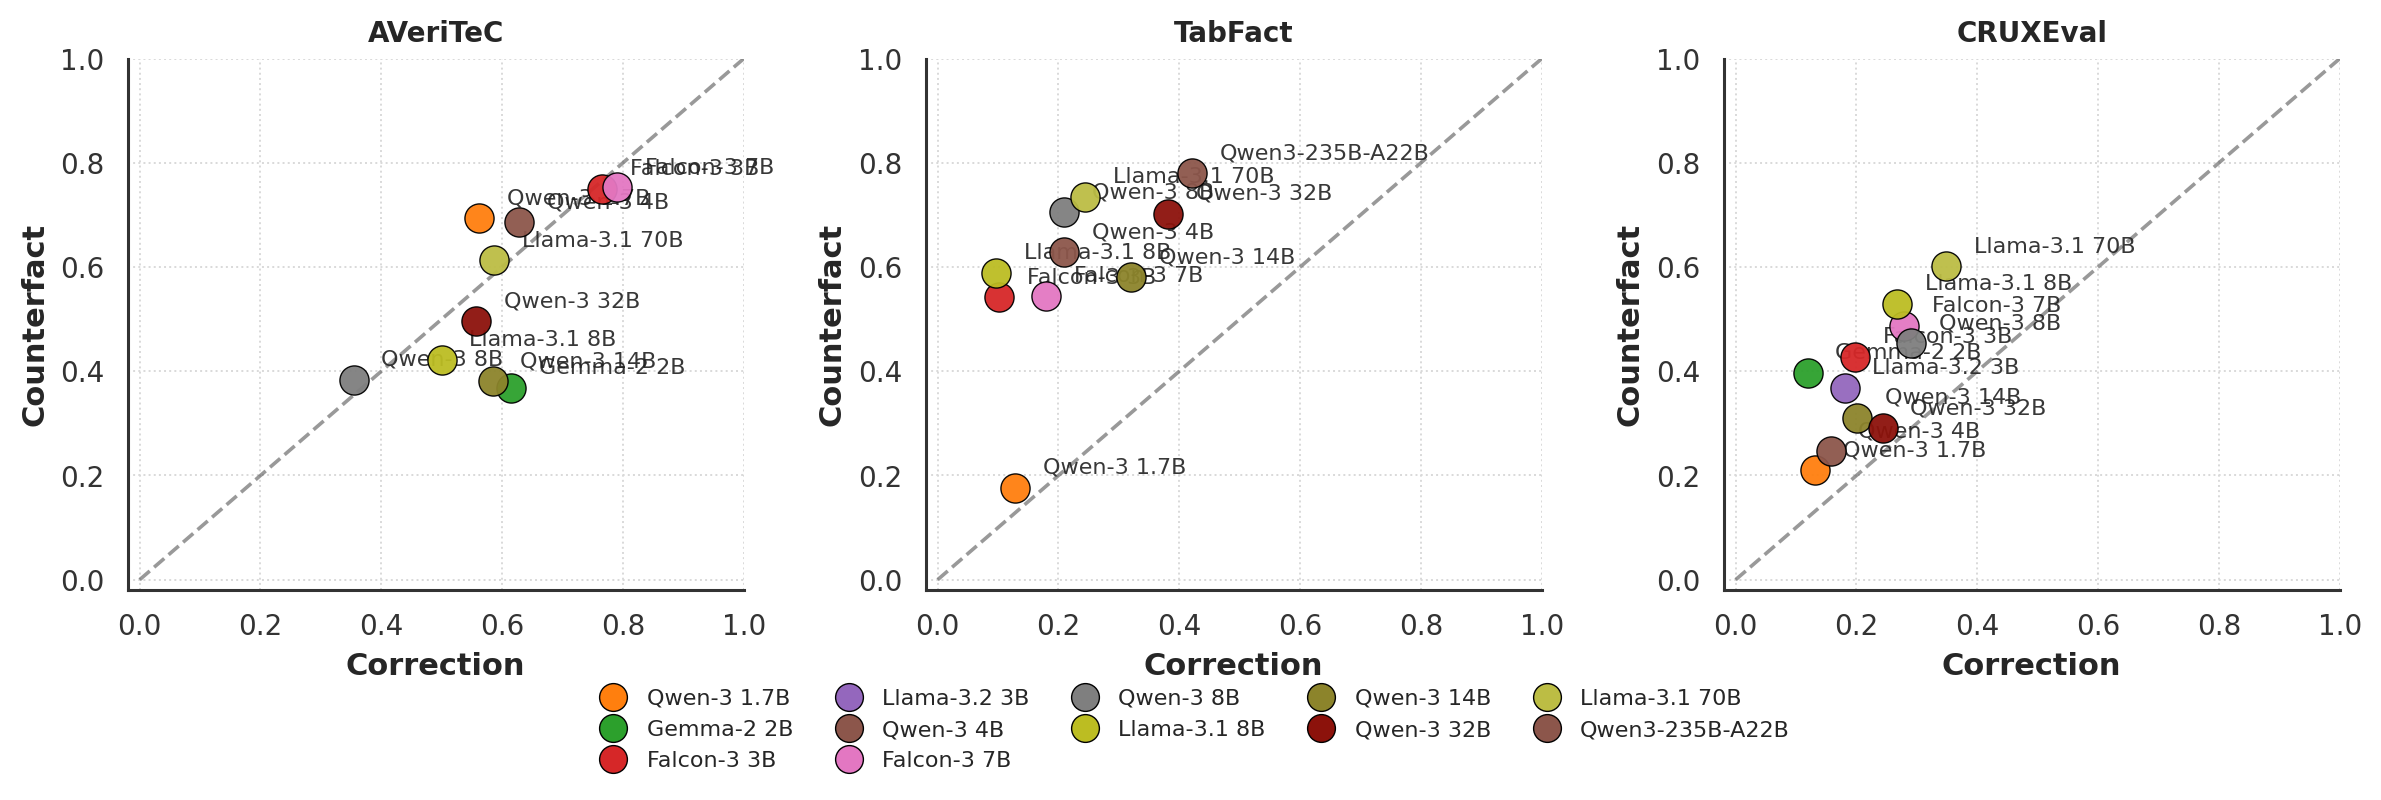

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

datasets = DATASET_ORDER
models = MODEL_ORDER

n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(4 * n_datasets, 4))

if n_datasets == 1:
    axes = [axes]

for idx, dataset in enumerate(datasets):
    ax = axes[idx]
    
    df_subset = df_standard[df_standard['dataset_name'] == dataset]
    
    summary_data = []
    for model in models:
        df_model = df_subset[df_subset['model_name_list'] == model]
        
        correction_df = df_model[df_model['intervention_type_list'] == 'correction']
        counterfact_df = df_model[df_model['intervention_type_list'] == 'counterfact']
        
        correction_mean = correction_df['id_ooId_faith_list'].mean()
        counterfact_mean = counterfact_df['id_ooId_faith_list'].mean()
        
        if ((len(correction_df) > 10) and (len(counterfact_df) > 10)):
            summary_data.append({
                'model': model,
                'correction': correction_mean,
                'counterfact': counterfact_mean
            })
    
    summary_df = pd.DataFrame(summary_data)
    
    ax.plot([0, 1], [0, 1],
            linestyle='--',
            linewidth=1.3,
            color="#555555",
            alpha=0.6,
            zorder=1,
            label='Symmetry')
    
    # Scatter plot for each model
    for _, row in summary_df.iterrows():
        ax.scatter(row['correction'], row['counterfact'], 
                  s=110,
                  color=model_colors[row['model']], 
                  edgecolors='black',  # Changed from 'white' to 'black'
                  linewidth=0.5,
                  alpha=0.95,
                  zorder=5)
        
        # Add model label with slight offset to avoid overlapping the point
        ax.annotate(row['model'], 
                   xy=(row['correction'], row['counterfact']),
                   xytext=(10, 5),
                   textcoords='offset points',
                   fontsize=LEGEND_FONT,
                   color="#222222",
                   alpha=0.9)
    
    # Styling for each subplot
    ax.set_xlim(-0.02, 1)
    ax.set_ylim(-0.02, 1)
    
    ax.set_xlabel('Correction', fontsize=XLABEL_SIZE)
    ax.set_ylabel('Counterfact', fontsize=YLABEL_SIZE)
    ax.set_title(dataset, fontsize=TITLE_SIZE)
    ax.tick_params(axis='x', labelsize=TICKS_SIZE)  # controls x-tick label size
    ax.tick_params(axis='y', labelsize=TICKS_SIZE)  # controls x-tick label size

    
    # Grid styling
    ax.grid(True)
    ax.set_axisbelow(True)

    # Clean spines
    sns.despine(ax=ax)

# Create horizontal legend below all subplots
legend_handles = []
for model, color in model_colors.items():
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                                      markerfacecolor=color, 
                                      markersize=10, 
                                      markeredgecolor='black', 
                                      markeredgewidth=0.5,
                                      label=model))

# Add legend below the figure
fig.legend(handles=legend_handles, 
           loc='lower center', 
           bbox_to_anchor=(0.5, 0), 
           ncol=5, 
           frameon=False, 
           fontsize=LEGEND_FONT,
           columnspacing=1.5,
           handletextpad=0.5)


plt.tight_layout(rect=[0, 0.1, 1, 1])  # Adjust layout to make room for legend
plt.savefig('symmetry_analysis.png', bbox_inches='tight', dpi=300)
plt.show()

### R3 Tool-use

Model order: ['Qwen-3 1.7B', 'Gemma-2 2B', 'Falcon-3 3B', 'Llama-3.2 3B', 'Qwen-3 4B', 'Falcon-3 7B', 'Qwen-3 8B', 'Llama-3.1 8B', 'Qwen-3 14B', 'Qwen-3 32B', 'Llama-3.1 70B', 'Qwen3-235B-A22B']
Found datasets: ['AVeriTeC', 'CRUXEval', 'TabFact']


/tmp/ipykernel_3247838/50157369.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregated = grouped.apply(compute_delta).reset_index()


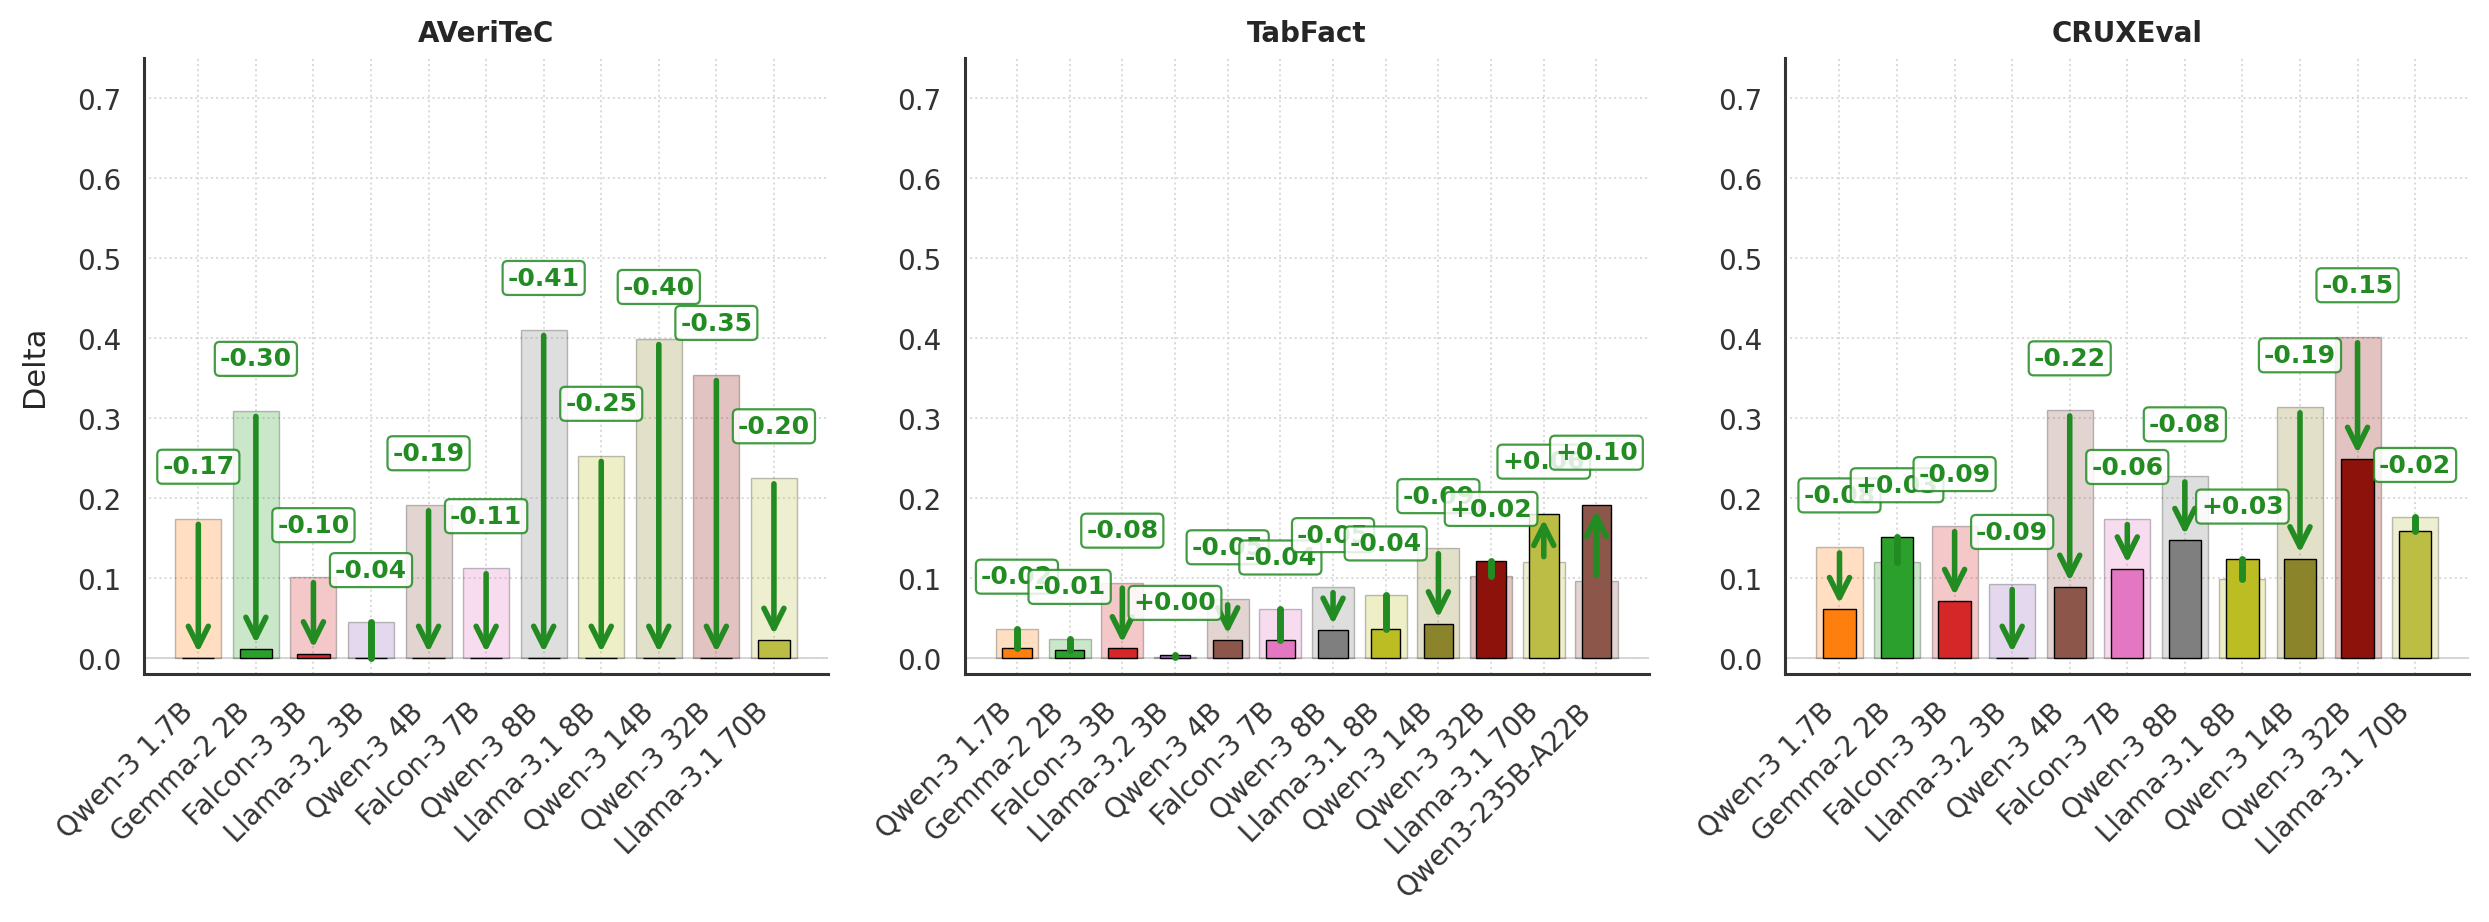

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch

# =============================================================================
# STEP 0: Define model order from your reference dataframe
# =============================================================================

model_order = MODEL_ORDER
print(f"Model order: {list(model_order)}")

# =============================================================================
# STEP 1: Prepare the data - CORRECT DELTA CALCULATION
# =============================================================================

# Group by dataset, model, run_type
grouped = df_exps.groupby(['dataset_name', 'model_name_list', 'run_type_list'])

# Compute mean of each metric separately, THEN compute delta
def compute_delta(group):
    id_mean = group['id_faith_list'].mean()
    ooid_mean = group['id_ooId_faith_list'].mean()
    return pd.Series({
        'id_mean': id_mean,
        'ooid_mean': ooid_mean,
        'delta': id_mean - ooid_mean  # ✅ Difference of means
    })

aggregated = grouped.apply(compute_delta).reset_index()

# Pivot to wide format: one row per (dataset, model), columns for 'standard' and 'tool'
pivot_df = aggregated.pivot_table(
    index=['dataset_name', 'model_name_list'], 
    columns='run_type_list', 
    values='delta', 
    aggfunc='first'  # Already aggregated, just reshape
).reset_index()

# Ensure both run types exist as columns
for col in ['standard', 'tool']:
    if col not in pivot_df.columns:
        pivot_df[col] = np.nan

# Get unique datasets
datasets = pivot_df['dataset_name'].unique()
print(f"Found datasets: {list(datasets)}")

# =============================================================================
# STEP 2: Create the visualization
# =============================================================================

n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(5 * n_datasets, 4))
if n_datasets == 1:
    axes = [axes]

# Styling parameters
transparent_alpha = 0.25
opaque_alpha = 1.0
bar_width = 0.8
arrow_color = 'forestgreen'
text_color = 'forestgreen'

datasets = DATASET_ORDER
all_datasets_list = []
for idx, (ax, dataset) in enumerate(zip(axes, datasets)):
    # Filter data for current dataset
    data = pivot_df[pivot_df['dataset_name'] == dataset].copy()
    
    # Filter AND ORDER models according to model_order
    data = data[data['model_name_list'].isin(model_order)]
    data['model_name_list'] = pd.Categorical(
        data['model_name_list'], 
        categories=model_order, 
        ordered=True
    )
    data = data.sort_values('model_name_list')
    
    data = data.dropna(subset=['standard', 'tool'], how='all')
    all_datasets_list.append(data)
    
    if len(data) == 0:
        ax.text(0.5, 0.5, 'No valid data', ha='center', va='center', 
               transform=ax.transAxes, fontsize=12, style='italic')
        ax.set_title(f'Dataset: {dataset}', fontsize=14, fontweight='bold', pad=20)
        continue
    
    # Prepare plot positions
    models = data['model_name_list'].tolist()
    x_pos = np.arange(len(models))
    
    standard_vals = data['standard'].values
    tool_vals = data['tool'].values
    
    # =========================================================================
    # Plot nested VERTICAL bars with MODEL-SPECIFIC COLORS
    # =========================================================================
    for i, model in enumerate(models):
        color = model_colors.get(model, '#999999')
        
        # Transparent wider bar = standard (baseline)
        ax.bar(x_pos[i], standard_vals[i], width=bar_width, color=color, 
                alpha=transparent_alpha, zorder=2, edgecolor='black', linewidth=0.5)
        
        # Opaque narrower bar = tool (intervention)
        ax.bar(x_pos[i], tool_vals[i], width=bar_width * 0.7, color=color, 
                alpha=opaque_alpha, zorder=2, edgecolor='black', linewidth=0.5)
    
    # =========================================================================
    # Add green connectors + delta text showing change from standard → tool
    # =========================================================================
    for i, (std, tool) in enumerate(zip(standard_vals, tool_vals)):
        if pd.isna(std) or pd.isna(tool):
            continue
            
        delta_change = tool - std
        delta_rounded = round(delta_change, 2)
        
        # # Arrow/line position: slightly offset from bar center
        # x_arrow = x_pos[i] + bar_width * 0.12
        x_arrow = x_pos[i]
        
        # ---- CHANGE 1: draw line instead of arrow if |delta| < 0.05 ----
        if abs(delta_change) < 0.05:
            # Draw a simple vertical line (no arrowhead)
            ax.plot([x_arrow, x_arrow], [std, tool], 
                    color=arrow_color, linewidth=2.5, zorder=3)
        else:
            arrow = FancyArrowPatch(
                (x_arrow, std), (x_arrow, tool),
                color=arrow_color, 
                arrowstyle='->', 
                linewidth=2.0, 
                mutation_scale=18,
                zorder=3
            )
            ax.add_patch(arrow)
        
        # ---- CHANGE 3: place delta text exactly above bars (centered) ----
        text_offset = 0.05
        text_y = max(std, tool) + text_offset
        # Use the bar's center x_pos[i] for exact horizontal centering
        text_x = x_pos[i]
        
        ax.text(text_x, text_y, f'{delta_rounded:+.2f}', 
               color=text_color, va='bottom', ha='center', fontsize=9, 
               fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', 
                                           facecolor='white', 
                                           edgecolor=arrow_color, 
                                           alpha=0.85),
               zorder=4)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, fontsize=TICKS_SIZE, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=TICKS_SIZE)
    ax.set_title(dataset, fontsize=TITLE_SIZE)
    
    # ---- CHANGE 2: ylabel only on leftmost subplot, horizontal, no bold ----
    if idx == 0:
        ax.set_ylabel('Delta', fontsize=YLABEL_SIZE, fontweight='normal', labelpad=10)
    
    ax.axhline(0, color='gray', linewidth=0.6, alpha=0.4, zorder=0)  # zero reference line
    
    ax.grid(True)
    ax.set_ylim(-0.02, 0.75)
    ax.set_axisbelow(True)

    # Clean spines
    sns.despine(ax=ax)

plt.savefig('tool_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [14]:
all_df_list_for_tool = pd.concat(all_datasets_list, axis=0)
# all_df_list_for_tool
all_df_list_for_tool = all_df_list_for_tool[['dataset_name', 'model_name_list', 'standard', 'tool']].round(2)
all_df_list_for_tool['delta'] = all_df_list_for_tool['standard'] - all_df_list_for_tool['tool']

In [15]:
all_df_list_for_tool.groupby(['dataset_name'])[['standard', 'tool', 'delta']].mean().to_markdown()

'| dataset_name   |   standard |       tool |     delta |\n|:---------------|-----------:|-----------:|----------:|\n| AVeriTeC       |  0.231818  | 0.00363636 | 0.228182  |\n| CRUXEval       |  0.200909  | 0.116364   | 0.0845455 |\n| TabFact        |  0.0758333 | 0.0566667  | 0.0191667 |'

### R4 Prompt

In [16]:
# 1. Create the pivot table
table = df_exps.pivot_table(
    index='model_name_list', 
    columns=['dataset_name', 'run_type_list'], 
    values='id_ooId_faith_list', 
    aggfunc='mean'
).round(3)

# 2. Define the desired order for prompt types (run_type_list)
prompt_order = ['standard', 'detailed', 'max_detailed']  # Adjust if your actual strings differ (e.g., 'Standard')

# 3. Reorder columns: for each dataset, sort sub-columns by prompt_order
# Get unique datasets
datasets = DATASET_ORDER

# 3. Reorder rows (models) according to MODEL_ORDER
# Filter to only include models that exist in the table
valid_models = MODEL_ORDER
table = table.reindex(index=valid_models)

# Build new column order list
new_columns = []
for ds in datasets:
    for prompt in prompt_order:
        # Check if this (dataset, prompt) combination exists in columns
        if (ds, prompt) in table.columns:
            new_columns.append((ds, prompt))

# Reindex columns to enforce order
table = table.reindex(columns=pd.MultiIndex.from_tuples(new_columns, names=['dataset_name', 'run_type_list']))
table = table.round(2)
# 4. Optional: Sort models alphabetically or by size (customize as needed)
# table = table.sort_index() 

# 5. Display
display(table)

dataset_name    AVeriTeC                        TabFact                        \
run_type_list   standard detailed max_detailed standard detailed max_detailed   
model_name_list                                                                 
Qwen-3 1.7B         0.60     0.60         0.66     0.08     0.06         0.06   
Gemma-2 2B          0.41     0.58         0.58     0.02     0.01         0.02   
Falcon-3 3B         0.75     0.75         0.72     0.10     0.10         0.09   
Llama-3.2 3B        0.09     0.12         0.11     0.00     0.00         0.00   
Qwen-3 4B           0.65     0.70         0.67     0.22     0.16         0.16   
Falcon-3 7B         0.76     0.72         0.70     0.16     0.15         0.16   
Qwen-3 8B           0.31     0.32         0.21     0.20     0.18         0.19   
Llama-3.1 8B        0.25     0.28         0.35     0.08     0.01         0.00   
Qwen-3 14B          0.46     0.49         0.65     0.34     0.36         0.35   
Qwen-3 32B          0.50     0.59         0.76     0.47     0.47         0.49   
Llama-3.1 70B       0.59     0.68         0.75     0.35     0.35         0.35   
Qwen3-235B-A22B      NaN      NaN          NaN     0.57     0.57         0.57   

dataset_name    CRUXEval                        
run_type_list   standard detailed max_detailed  
model_name_list                                 
Qwen-3 1.7B         0.12     0.07         0.06  
Gemma-2 2B          0.18     0.20         0.20  
Falcon-3 3B         0.25     0.28         0.27  
Llama-3.2 3B        0.14     0.20         0.21  
Qwen-3 4B           0.16     0.19         0.18  
Falcon-3 7B         0.28     0.28         0.29  
Qwen-3 8B           0.32     0.30         0.31  
Llama-3.1 8B        0.22     0.25         0.25  
Qwen-3 14B          0.23     0.22         0.23  
Qwen-3 32B          0.26     0.25         0.26  
Llama-3.1 70B       0.42     0.47         0.45  
Qwen3-235B-A22B      NaN      NaN          NaN

In [17]:
# 1. Group by prompt type and dataset, calculate mean and std across all models
summary = df_exps.groupby(['run_type_list', 'dataset_name'])['id_ooId_faith_list'].agg(['mean', 'std']).round(3)

# 2. Format as "mean ± std"
summary['value'] = summary.apply(lambda row: f"{round(row['mean'], 2)} ± {round(row['std'], 2)}", axis=1)

# 3. Pivot to get prompt types as rows, datasets as columns
table_small = summary['value'].unstack(level='dataset_name')

# 4. Reorder rows and columns to match your preferred order
PROMPT_ORDER = ['standard', 'detailed', 'max_detailed']  # Adjust case if needed
DATASET_ORDER = DATASET_ORDER  # Or use nice names

# Filter to existing indices/columns and reindex
table_small = table_small.reindex(
    index=[p for p in PROMPT_ORDER if p in table_small.index],
    columns=[d for d in DATASET_ORDER if d in table_small.columns]
)

# 6. Display
display(table_small)

dataset_name,AVeriTeC,TabFact,CRUXEval
run_type_list,,,
standard,0.49 ± 0.5,0.21 ± 0.41,0.24 ± 0.42
detailed,0.53 ± 0.5,0.2 ± 0.4,0.25 ± 0.43
max_detailed,0.56 ± 0.5,0.2 ± 0.4,0.25 ± 0.43
